## Part 1: Review of Week 4 Foundation

Before beginning Week 5 practical work, this section will briefly review the foundation established in Week 4.

**1. Problem Defined**

The project addresses missed appointments at HealthConnect Clinic. It was framed as a binary classification problem: predicting appointment_outcome (Attended vs No-Show) using patient and appointment information.

**2. Week 4 Proposed Approach**

Eleven candidate features were identified, spanning patient demographics, appointment history, reminder information, and logistics (distance, waiting time). Logistic Regression was proposed as the initial baseline model, with Random Forest flagged as a possible future addition.

**3. Resources Used**
- HealthConnect_Appointment_Data.csv
- HealthConnect_Data_Dictionary.xlsx

**4. Key Assumptions / Limitations Identified**
- Missing data in distance_to_clinic_km and waiting_time_minutes would require median imputation.
- Features such as gender and age were treated as untested hypotheses, not confirmed predictors.
- The dataset contains 5,000 appointments across only 1,696 unique patients, so a standard random train/test split risks patient overlap between sets, so a patient-level split was proposed instead.
- Feature availability at the prediction point needed to be confirmed to avoid data leakage.

**5. Proposed Focus for Week 5**

Statistically test the relationship between each candidate feature and appointment_outcome, finalise the feature list based on this analysis, and begin initial model training using the Logistic Regression baseline.

## Part 2, Task 1: Review of Week 4 ML Problem Definition

- **Prediction problem:**

    Predict whether a scheduled appointment will be Attended or result in a No-Show.

- **Proposed target:**

    appointment_outcome was choosen as the proposed target and later encoded as 0 = Attended, 1 = No-Show.

- **Candidate features (Week 4):**
  
    About 11 featues were selected and they are age, age_group, gender, appointment_type, booking_lead_days, previous_appointments, previous_no_shows, reminder_sent, reminder_channel, distance_to_clinic_km, waiting_time_minutes, appointment_day, appointment_time.

- **Treatment of cancellations:**

    Cancelled appointments will be excluded from the modelling dataset, since a cancellation is a patient-initiated, known absence rather than an unpredicted no-show.
- **Modelling objective:**

    Establish an interpretable baseline classifier (Logistic Regression) that flags appointments at risk of no-show, so the clinic can intervene (e.g. additional reminders) before the slot is lost.

### Note on Processed Dataset

In Week 4, cancelled appointments were excluded and appointment_outcome was encoded (0 = Attended, 1 = No-Show) to produce a modelling-ready dataset (health_connect_ml). However, this derived dataset was not saved to a separate file at the time.

For Week 5, this transformation is re-applied to the original raw dataset (HealthConnect_Appointment_Data.csv, which remains unchanged) and the result is now saved as a new, separate file called HealthConnect_ML_Processed.csv. 

This ensures that the derived dataset is documented and persists for the remainder of the project, in line with the requirement not to overwrite original project resources.

In [99]:
## importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
health_connect_appointment = pd.read_csv("HealthConnect_Appointment_Data.csv")
health_connect_appointment.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [101]:
health_connect_ml = health_connect_appointment[health_connect_appointment['appointment_outcome'] != 'Cancelled'].copy()
health_connect_ml['appointment_outcome'] = health_connect_ml['appointment_outcome'].map({'Attended': 0, 'No-Show': 1})

In [102]:
health_connect_ml.to_csv("HealthConnect_ML_Processed.csv", index=False)

In [103]:
HealthConnect_ML_Processed = pd.read_csv("HealthConnect_ML_Processed.csv")
HealthConnect_ML_Processed.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,1
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,0
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,1
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,0
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,1


In [104]:
HealthConnect_ML_Processed.shape

(4737, 18)

In [105]:
HealthConnect_ML_Processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4737 entries, 0 to 4736
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         4737 non-null   object 
 1   patient_id             4737 non-null   object 
 2   gender                 4737 non-null   object 
 3   age                    4737 non-null   int64  
 4   age_group              4737 non-null   object 
 5   appointment_type       4737 non-null   object 
 6   booking_date           4737 non-null   object 
 7   appointment_date       4737 non-null   object 
 8   appointment_day        4737 non-null   object 
 9   appointment_time       4737 non-null   object 
 10  booking_lead_days      4737 non-null   int64  
 11  previous_appointments  4737 non-null   int64  
 12  previous_no_shows      4737 non-null   int64  
 13  reminder_sent          4737 non-null   object 
 14  reminder_channel       3452 non-null   object 
 15  dist

In [106]:
HealthConnect_ML_Processed.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1285
distance_to_clinic_km      86
waiting_time_minutes       58
appointment_outcome         0
dtype: int64

In [107]:
HealthConnect_ML_Processed.duplicated().sum()

np.int64(0)

In [108]:
HealthConnect_ML_Processed['appointment_id'].duplicated().sum()

np.int64(0)

In [109]:
HealthConnect_ML_Processed['patient_id'].nunique()

1680

In [110]:
categorical_cols = ['gender', 'appointment_type', 'reminder_sent', 'reminder_channel', 
                     'appointment_day', 'appointment_time', 'appointment_outcome', 'age_group']

for col in categorical_cols:
    print(col, ":", HealthConnect_ML_Processed[col].unique())
    print()

gender : ['Female' 'Male' 'Prefer not to say']

appointment_type : ['Follow-up' 'Specialist Consultation' 'General Consultation'
 'Diagnostic Test']

reminder_sent : ['Yes' 'No']

reminder_channel : ['WhatsApp' 'SMS' 'Email' nan]

appointment_day : ['Tuesday' 'Friday' 'Wednesday' 'Thursday' 'Monday' 'Sunday' 'Saturday']

appointment_time : ['Afternoon' 'Morning' 'Evening']

appointment_outcome : [1 0]

age_group : ['35-44' '25-34' '45-54' '55-64' '65+' '18-24']



### Task 2a: Data Preparation Summary

The processed dataset (**HealthConnect_ML_Processed.csv**) contains 4,737 records across 18 columns, after excluding 263 Cancelled appointments from the original 5,000.

**Missing values:** 

Three fields contain missing values namely: reminder_channel, distance_to_clinic_km, and waiting_time_minutes. reminder_channel missing data is fully explained because it aligns exactly with appointments where reminder_sent = No. The other two will require imputation before modelling.

**Duplicates:** 

No fully duplicated rows were found, and no duplicate appointment_id values exist, confirming the primary key is clean.

**Data types:** 

All variables have data types consistent with the Data Dictionary. booking_date and appointment_date are stored as text (object) rather than datetime, but since booking_lead_days and appointment_day already provide the relevant derived information, this is left as it is.

**Categorical consistency:**

All categorical variables are clean and match the Data Dictionary, with one exception of gender which contains three categories (Female, Male, Prefer not to say) rather than a binary split. This is left unaltered, since merging categories would misrepresent those patients.

**Irrelevant variables:** 

appointment_id and patient_id are unique identifiers with no predictive value (though patient_id will be used for the patient-level train/test split). 
These two variables will be excluded from the model input features

**Note on waiting_time_minutes:** 

The Data Dictionary describes this as an *estimated* waiting time rather than a value recorded only after arrival, so it does not carry an obvious leakage risk. Its relationship with the outcome will be examined properly, alongside the other candidate features, in Task 2b.

**Patients:** 

The dataset spans 1,680 unique patients across 4,737 appointments, confirming that many patients have multiple appointments. This is relevant to the train/test split strategy planned later in this notebook.

### Task 2: Data Exploration & Visual Evidence
#### Numerical Analysis

In [111]:
HealthConnect_ML_Processed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4737 entries, 0 to 4736
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         4737 non-null   object 
 1   patient_id             4737 non-null   object 
 2   gender                 4737 non-null   object 
 3   age                    4737 non-null   int64  
 4   age_group              4737 non-null   object 
 5   appointment_type       4737 non-null   object 
 6   booking_date           4737 non-null   object 
 7   appointment_date       4737 non-null   object 
 8   appointment_day        4737 non-null   object 
 9   appointment_time       4737 non-null   object 
 10  booking_lead_days      4737 non-null   int64  
 11  previous_appointments  4737 non-null   int64  
 12  previous_no_shows      4737 non-null   int64  
 13  reminder_sent          4737 non-null   object 
 14  reminder_channel       3452 non-null   object 
 15  dist

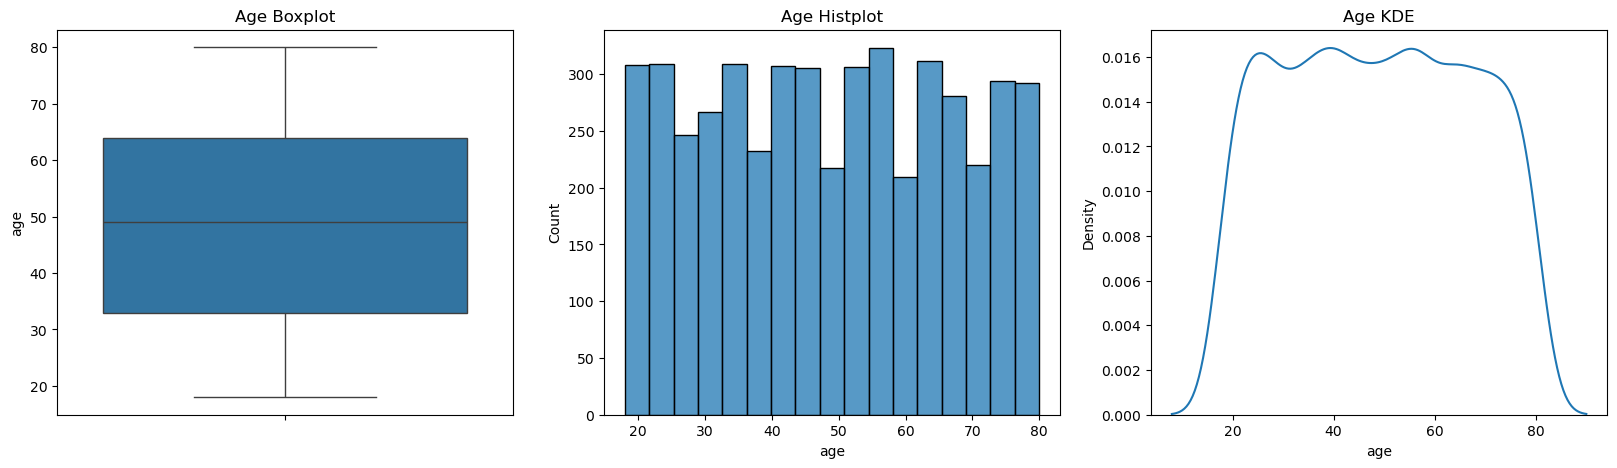

In [112]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['age'], ax = axes[0])
axes[0].set_title('Age Boxplot')

sns.histplot(x= HealthConnect_ML_Processed['age'], ax = axes[1])
axes[1].set_title('Age Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['age'], ax = axes[2])
axes[2].set_title('Age KDE')

plt.show()

**Age**: 

The boxplot shows no outliers. The histogram and KDE show a roughly flat/uniform distribution between 20 and 80 years, with no strong skew. No transformation or special handling is needed for this variable.

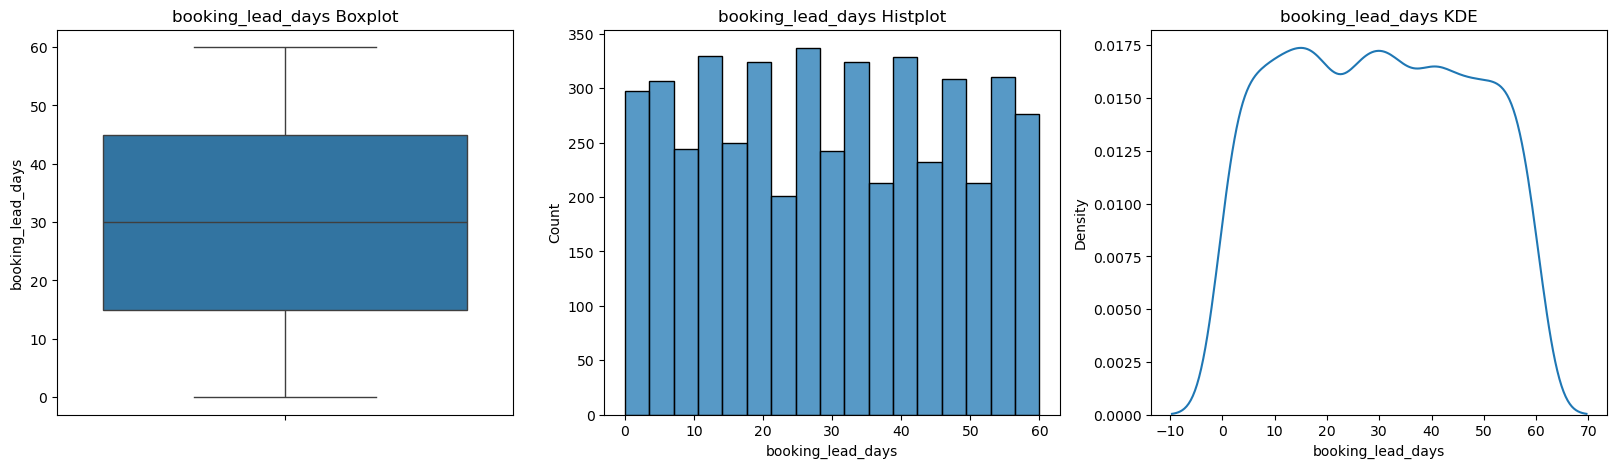

In [113]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['booking_lead_days'], ax = axes[0])
axes[0].set_title('booking_lead_days Boxplot')

sns.histplot(x= HealthConnect_ML_Processed['booking_lead_days'], ax = axes[1])
axes[1].set_title('booking_lead_days Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['booking_lead_days'], ax = axes[2])
axes[2].set_title('booking_lead_days KDE')

plt.show()

**Booking Lead Days**: 

The boxplot shows no outliers. The histogram and KDE show a roughly uniform distribution between 0 and 60 days, with no strong skew. No transformation or special handling is needed for this variable.

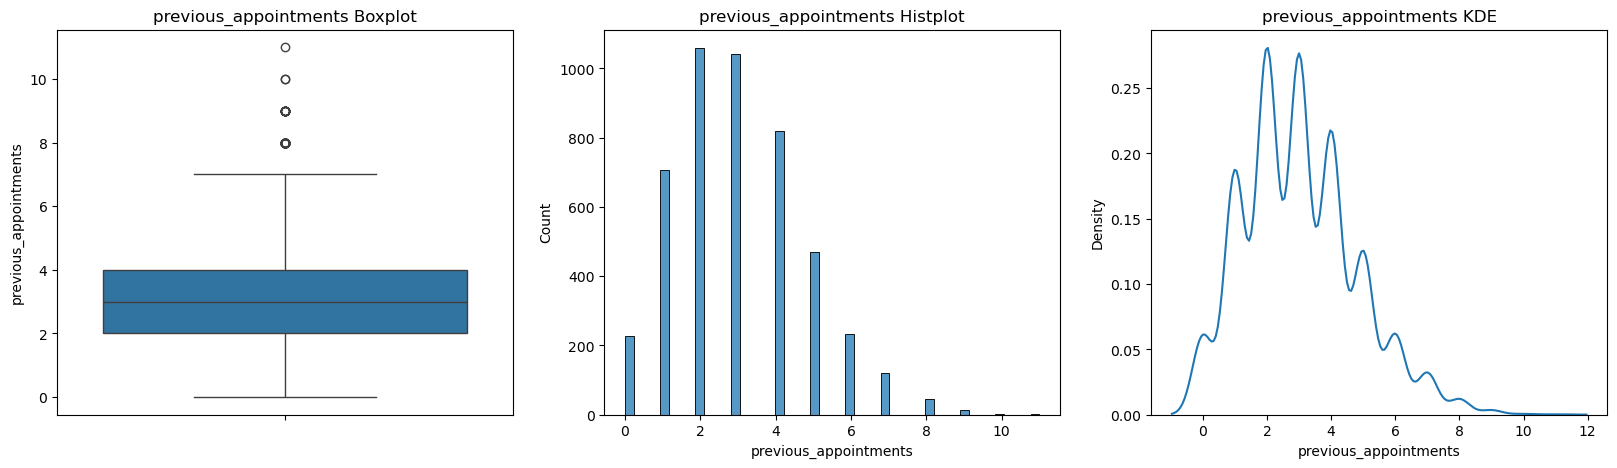

In [114]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['previous_appointments'], ax = axes[0])
axes[0].set_title('previous_appointments Boxplot')

sns.histplot(x= HealthConnect_ML_Processed['previous_appointments'], ax = axes[1])
axes[1].set_title('previous_appointments Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['previous_appointments'], ax = axes[2])
axes[2].set_title('previous_appointments KDE')

plt.show()

**Previous Appointments**: 

The boxplot shows several outliers above 8 previous appointments. The histogram and KDE confirm a right-skewed distribution, with most patients having 1–5 prior appointments and a smaller number with a long history of visits. These are treated as legitimate values and such can be seen in patients with chronic conditions attending frequently. These are not errors and therefore are not removed. 

The skew supports scaling this feature before modelling.

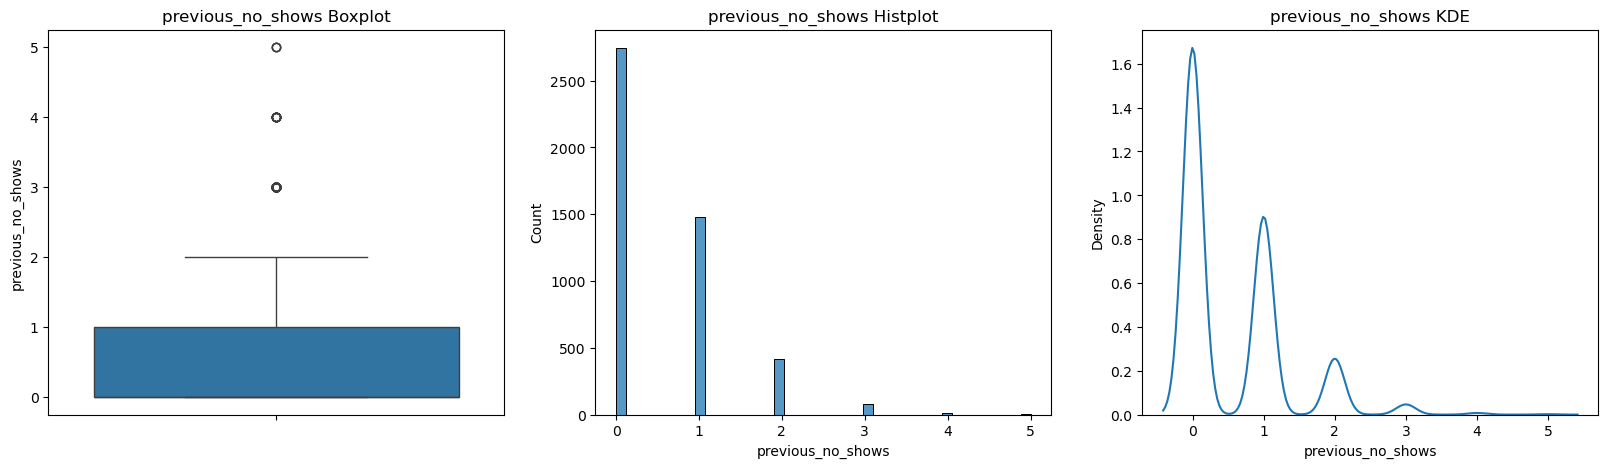

In [115]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['previous_no_shows'], ax = axes[0])
axes[0].set_title('previous_no_shows Boxplot')

sns.histplot(x= HealthConnect_ML_Processed['previous_no_shows'], ax = axes[1])
axes[1].set_title('previous_no_shows Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['previous_no_shows'], ax = axes[2])
axes[2].set_title('previous_no_shows KDE')

plt.show()

**Previous No-Shows**: 

The boxplot shows outliers at 3–5 previous no-shows. The histogram and KDE show a strongly right-skewed distribution, with most patients having 0 previous no-shows and a small minority with a repeated history of missed appointments. These values are treated as legitimate, not errors. The strong skew supports scaling this feature.

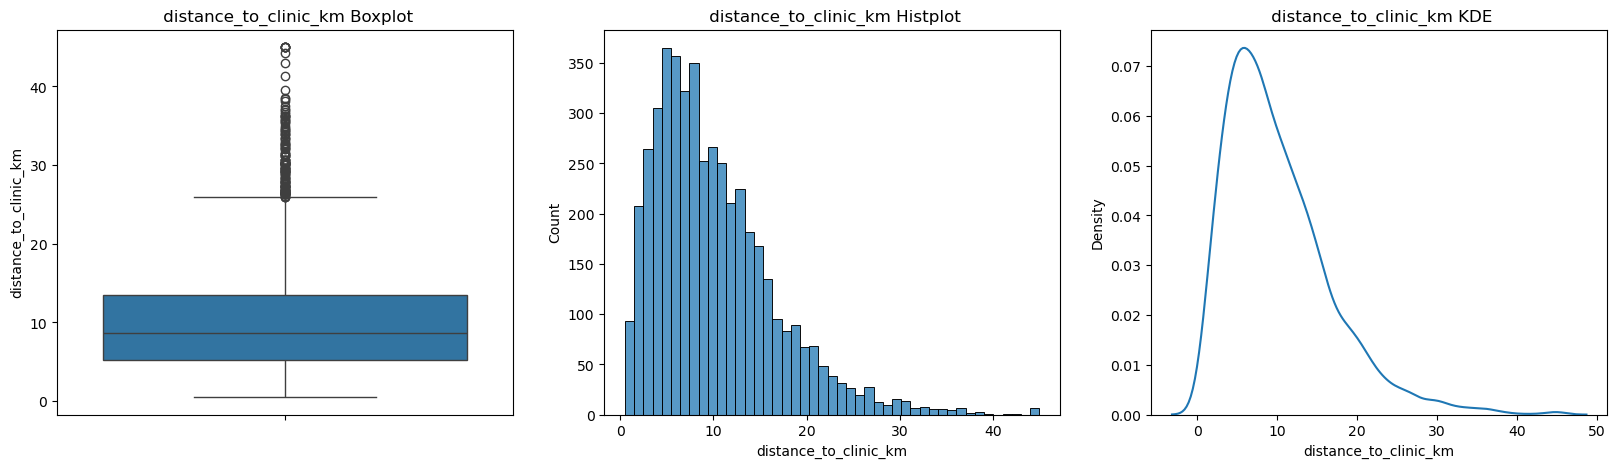

In [116]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['distance_to_clinic_km'], ax = axes[0])
axes[0].set_title(' distance_to_clinic_km Boxplot')

sns.histplot(x= HealthConnect_ML_Processed['distance_to_clinic_km'], ax = axes[1])
axes[1].set_title(' distance_to_clinic_km Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['distance_to_clinic_km'], ax = axes[2])
axes[2].set_title(' distance_to_clinic_km KDE')

plt.show()

**Distance to Clinic (km)**: 

Plotted on the 4,651 non-missing records (86 missing values excluded). The boxplot shows numerous outliers beyond 25km, extending to nearly 45km. The histogram and KDE confirm a strongly right-skewed distribution, with most patients living within 0–15km of the clinic and a smaller number living much further away. These outliers are treated as legitimate (patients who genuinely live far from the clinic), not errors. The skew supports the planned median imputation for the missing values, and scaling this feature before modelling.

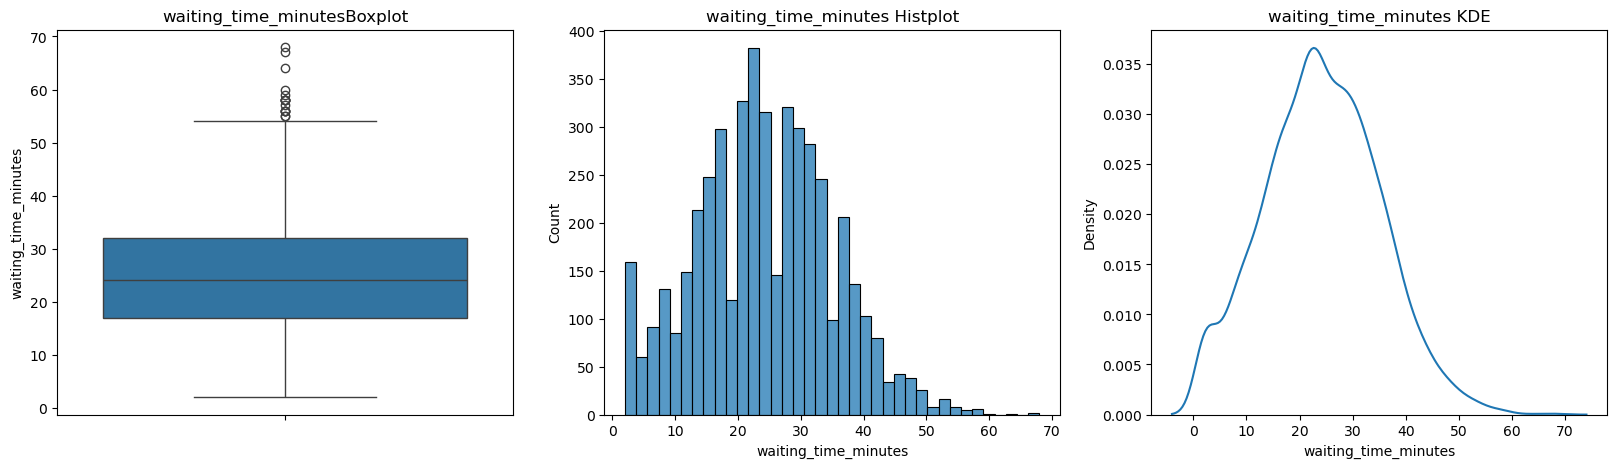

In [117]:
fig,axes = plt.subplots(1,3, figsize= (20,5))

sns.boxplot(y =HealthConnect_ML_Processed['waiting_time_minutes'], ax = axes[0])
axes[0].set_title('waiting_time_minutesBoxplot')

sns.histplot(x= HealthConnect_ML_Processed['waiting_time_minutes'], ax = axes[1])
axes[1].set_title('waiting_time_minutes Histplot')

sns.kdeplot(x = HealthConnect_ML_Processed['waiting_time_minutes'], ax = axes[2])
axes[2].set_title('waiting_time_minutes KDE')

plt.show()

**Waiting Time (minutes)**: 

Plotted on the 4,679 non-missing records (58 missing values excluded). The boxplot shows outliers above 54 minutes, extending to 70. The histogram and KDE show a moderately right-skewed distribution, peaking around 20–25 minutes with a longer tail toward 60–70 minutes. These outliers are treated as plausible clinic delays, not errors. The skew supports median imputation for the missing values, consistent with the approach used for distance_to_clinic_km.

##### Handling Missing Values

Based on the distributions explored above, distance_to_clinic_km and waiting_time_minutes are both moderately to strongly right-skewed, with outliers rather than data errors. Given this skew, the mean would be pulled by the tail and misrepresent a typical value, so median imputation is used for both variables instead.

reminder_channel's missing values are not imputed here, as they were already shown to align exactly with reminder_sent = No, they are not missing at random but structurally absent (no reminder was sent, so no channel exists). This will instead be handled explicitly during categorical encoding.

In [118]:
median_distance = HealthConnect_ML_Processed['distance_to_clinic_km'].median()
median_waiting_time = HealthConnect_ML_Processed['waiting_time_minutes'].median()

HealthConnect_ML_Processed['distance_to_clinic_km'] = HealthConnect_ML_Processed['distance_to_clinic_km'].fillna(median_distance)
HealthConnect_ML_Processed['waiting_time_minutes'] = HealthConnect_ML_Processed['waiting_time_minutes'].fillna(median_waiting_time)

In [119]:
HealthConnect_ML_Processed[['distance_to_clinic_km', 'waiting_time_minutes']].isnull().sum()

distance_to_clinic_km    0
waiting_time_minutes     0
dtype: int64

#### Categorical Analysis

In [120]:
HealthConnect_ML_Processed.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome        int64
dtype: object

In [121]:
HealthConnect_ML_Processed['gender'].value_counts()

gender
Female               2358
Male                 2274
Prefer not to say     105
Name: count, dtype: int64

In [122]:
HealthConnect_ML_Processed['gender'].value_counts(normalize = True)

gender
Female               0.497783
Male                 0.480051
Prefer not to say    0.022166
Name: proportion, dtype: float64

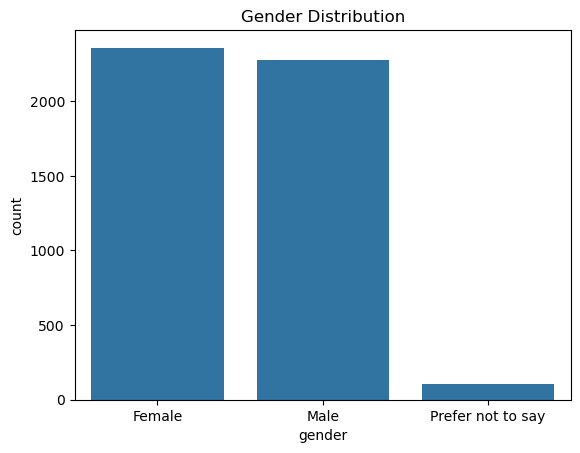

In [123]:
sns.countplot(x='gender', data= HealthConnect_ML_Processed)
plt.title('Gender Distribution')
plt.show()

**Gender**:

The distribution is roughly balanced between Female (49.8%) and Male (48.0%), with a small "Prefer not to say" group (2.2%, n=105). This category is retained rather than merged or dropped, since it represents a real patient response. Its small size will be noted as a limitation when interpreting any statistical relationship between gender and appointment outcome.

In [124]:
HealthConnect_ML_Processed['age_group'].value_counts()

age_group
65+      1165
35-44     770
55-64     766
25-34     750
45-54     746
18-24     540
Name: count, dtype: int64

In [125]:
HealthConnect_ML_Processed['age_group'].value_counts(normalize = True)

age_group
65+      0.245936
35-44    0.162550
55-64    0.161706
25-34    0.158328
45-54    0.157484
18-24    0.113996
Name: proportion, dtype: float64

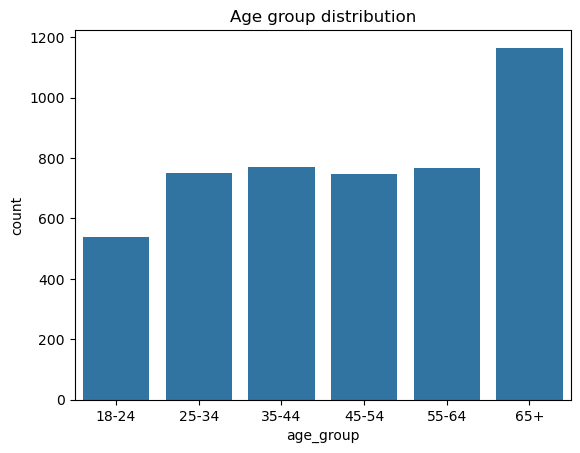

In [126]:
sns.countplot(x= 'age_group',order=['18-24','25-34','35-44','45-54','55-64','65+'],data = HealthConnect_ML_Processed)
plt.title('Age group distribution')
plt.show()

**Age Group**: 

The distribution shows a noticeably larger count for the "65+" band compared to the other bands, which follow fixed 10-year windows. This reflects the wider, open-ended range of the "65+" bin rather than an unusual concentration of elderly patients which is consistent with the roughly uniform distribution seen in the age histogram. No data-quality issue is indicated.

In [127]:
HealthConnect_ML_Processed['appointment_type'].value_counts()

appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

In [128]:
HealthConnect_ML_Processed['appointment_type'].value_counts(normalize = True
                                                        )

appointment_type
General Consultation       0.417986
Follow-up                  0.283724
Specialist Consultation    0.178594
Diagnostic Test            0.119696
Name: proportion, dtype: float64

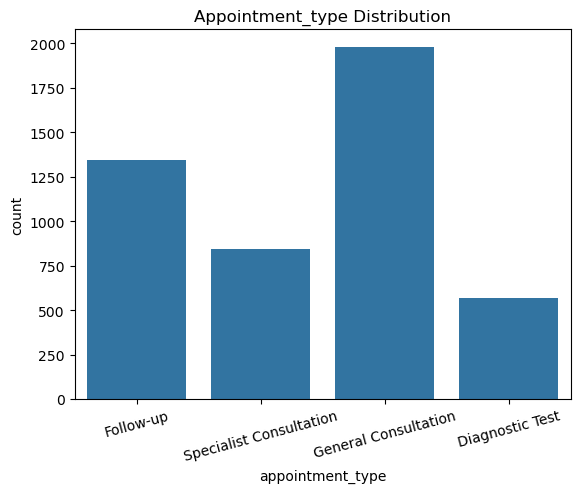

In [129]:
sns.countplot(x='appointment_type', data= HealthConnect_ML_Processed)
plt.title('Appointment_type Distribution')
plt.xticks(rotation=15)
plt.show()

**Appointment Type**: 

General Consultation is the most frequent appointment type (1,980), followed by Follow-up (1,344), Specialist Consultation (846), and Diagnostic Test (567). 
All categories have sufficient sample sizes for reliable statistical testing later. No data-quality issues observed.

In [130]:
HealthConnect_ML_Processed['appointment_day'].value_counts()

appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

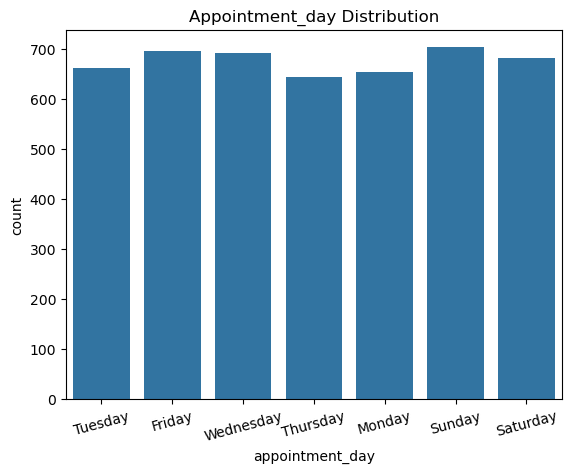

In [131]:
sns.countplot(x='appointment_day', data= HealthConnect_ML_Processed)
plt.title('Appointment_day Distribution')
plt.xticks(rotation=15)
plt.show()

**Appointment Day**: 

Appointments are fairly evenly distributed across all seven days of the week (roughly 645–705 each), including weekends. No day is disproportionately represented, and no data-quality issues are observed.

In [132]:
HealthConnect_ML_Processed['appointment_time'].value_counts()

appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64

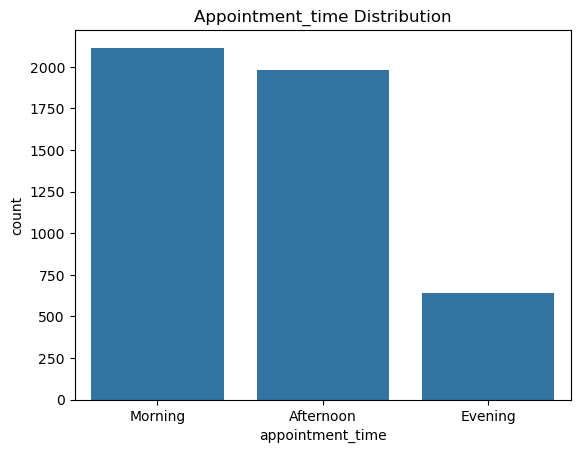

In [133]:
sns.countplot(x='appointment_time',order =['Morning', 'Afternoon', 'Evening'], data= HealthConnect_ML_Processed)
plt.title('Appointment_time Distribution')
plt.show()

**Appointment Time**: 

Morning (2,116) and Afternoon (1,979) appointments are most common, while Evening (642) is noticeably fewer. This is consistent with clinics typically offering fewer evening slots. All three categories have sufficient sample sizes for statistical testing, though Evening's smaller count will be kept in mind when interpreting results.

In [134]:
HealthConnect_ML_Processed['reminder_sent'].value_counts()

reminder_sent
Yes    3452
No     1285
Name: count, dtype: int64

In [135]:
HealthConnect_ML_Processed['reminder_sent'].value_counts(normalize = True)

reminder_sent
Yes    0.728731
No     0.271269
Name: proportion, dtype: float64

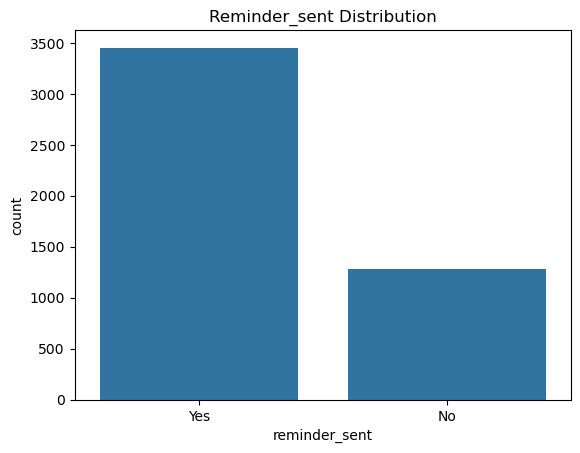

In [136]:
sns.countplot(x='reminder_sent', data= HealthConnect_ML_Processed)
plt.title('Reminder_sent Distribution')
plt.show()

**Reminder Sent**: 

The majority of patients (73%, n≈3,450) received a reminder, while 27% (n≈1,285) did not. This count aligns with the earlier finding that missing reminder_channel values correspond exactly to reminder_sent = No, confirming internal consistency in the data. Both categories are large enough for reliable statistical testing.

In [137]:
HealthConnect_ML_Processed['reminder_channel'].value_counts()

reminder_channel
SMS         1907
WhatsApp    1039
Email        506
Name: count, dtype: int64

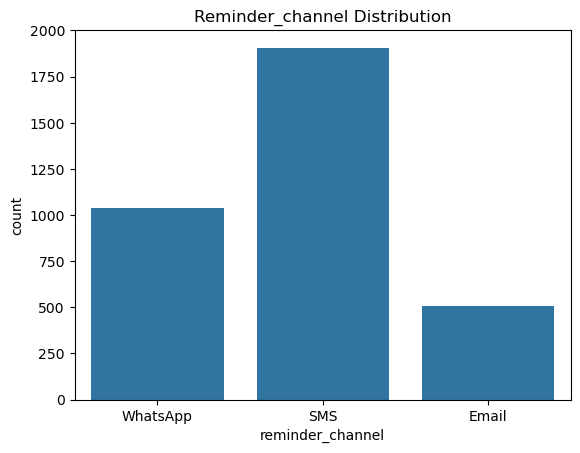

In [138]:
sns.countplot(x='reminder_channel', data= HealthConnect_ML_Processed)
plt.title('Reminder_channel Distribution')
plt.show()

**Reminder Channel**: 

Among patients who received a reminder, SMS was the most common channel (1,907), followed by WhatsApp (1,039) and Email (506). Missing values here correspond exactly to patients with reminder_sent = No, consistent with earlier findings. All three categories are large enough for reliable statistical testing.

#### Target Variable Analysis

In [139]:
HealthConnect_ML_Processed['appointment_outcome'].value_counts()

appointment_outcome
1    2423
0    2314
Name: count, dtype: int64

In [140]:
HealthConnect_ML_Processed['appointment_outcome'].value_counts(normalize = True)

appointment_outcome
1    0.511505
0    0.488495
Name: proportion, dtype: float64

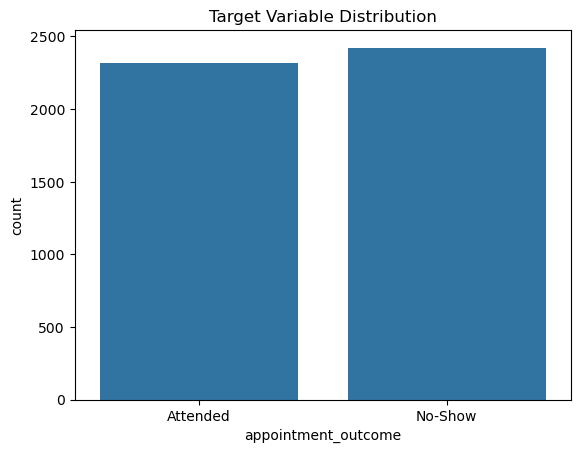

In [141]:
sns.countplot(x='appointment_outcome', data= HealthConnect_ML_Processed)
plt.title('Target Variable Distribution')
plt.xticks([0, 1], ['Attended', 'No-Show'])
plt.show()

The target variable appointment_outcome is nearly balanced: 2,314 Attended (48.9%) vs 2,423 No-Show (51.1%). This balance is favourable for baseline modelling, since it means accuracy will be a reasonably meaningful metric without needing techniques like class rebalancing (e.g. SMOTE) at this stage.

### Multivariate Analysis: Correlation Heatmap

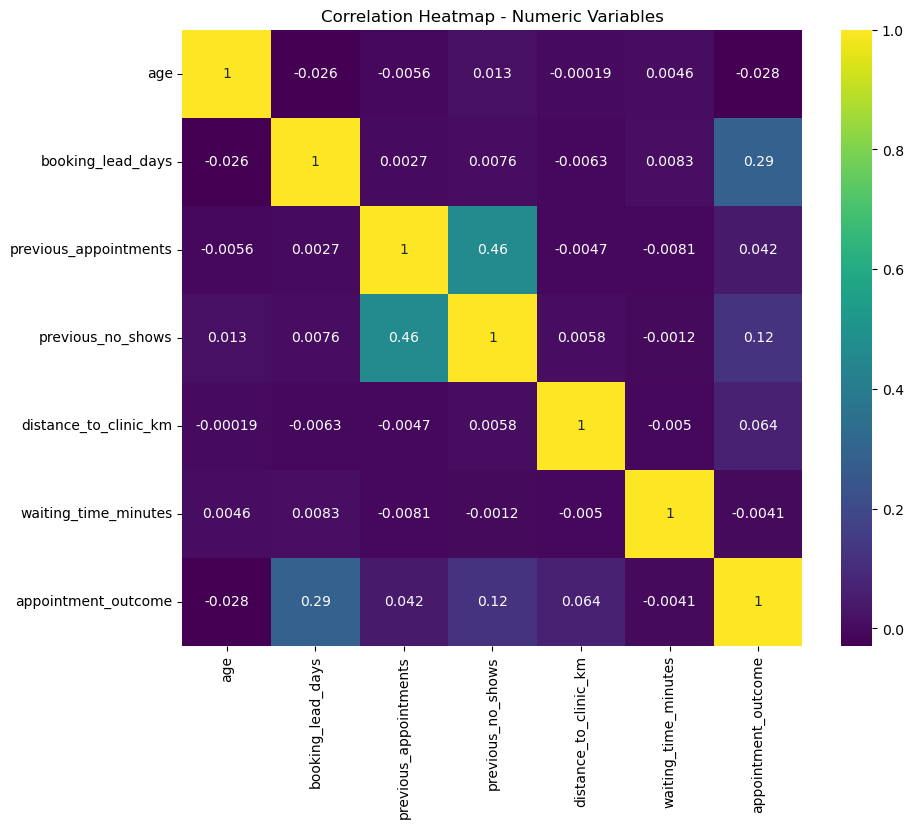

In [142]:
plt.figure(figsize=(10,8))
sns.heatmap(HealthConnect_ML_Processed.corr(numeric_only=True), annot=True, cmap='viridis')
plt.title('Correlation Heatmap - Numeric Variables')
plt.show()

### Feature Target relationship
1. appointment outcome vs booking_lead_days

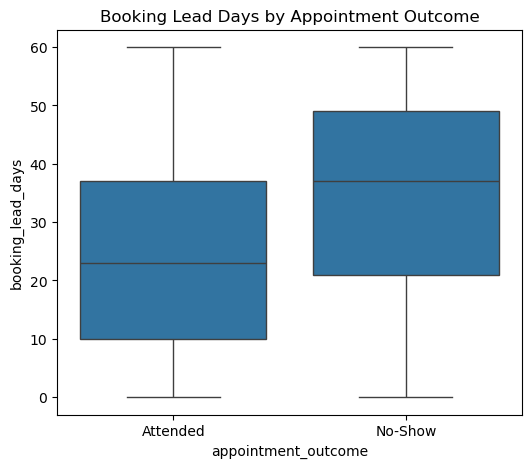

In [143]:
plt.figure(figsize=(6,5))
sns.boxplot(x='appointment_outcome', y='booking_lead_days', data=HealthConnect_ML_Processed)
plt.xticks([0, 1], ['Attended', 'No-Show'])
plt.title('Booking Lead Days by Appointment Outcome')
plt.show()

**Booking Lead Days by Outcome**:

Patients who missed their appointment had booked further in advance on average (37 days) compared to patients who attended (23 days). The two groups barely overlap, meaning this is a real, visible difference. This makes sense logically, the longer someone waits between booking and the actual appointment, the more likely they are to forget, have a conflict come up, or simply feel less urgency about it by the time the date arrives. This is a strong feature to keep for the model.

2. Previous no shows vs Appointment Outcome

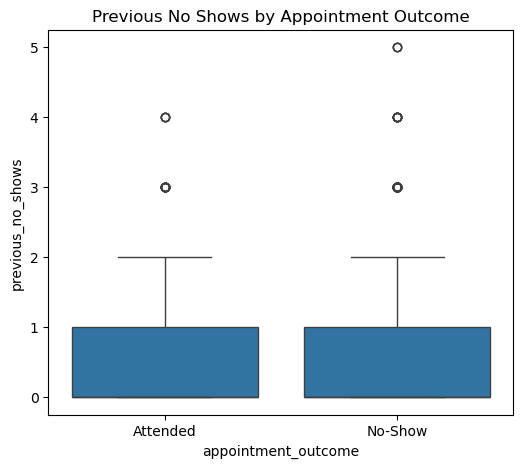

In [144]:
plt.figure(figsize=(6,5))
sns.boxplot(x='appointment_outcome', y='previous_no_shows', data=HealthConnect_ML_Processed)
plt.xticks([0, 1], ['Attended', 'No-Show'])
plt.title('Previous No Shows by Appointment Outcome')
plt.show()

**Previous No-Shows by Outcome**: 

The boxplot shows both groups (Attended and No-Show) with a very similar shape, same median (0) and similar spread, with no obvious visual difference. This is likely because most patients in the dataset have 0 previous no-shows (as seen in the earlier distribution), leaving little variation for a strong relationship to emerge. This is consistent with the weak correlation (0.12) seen in the heatmap. This variable's relationship with the outcome will be confirmed through formal statistical testing later in the analysis.

#### Categorical Features Target relationship

3. appointment_type vs appointment_outcome

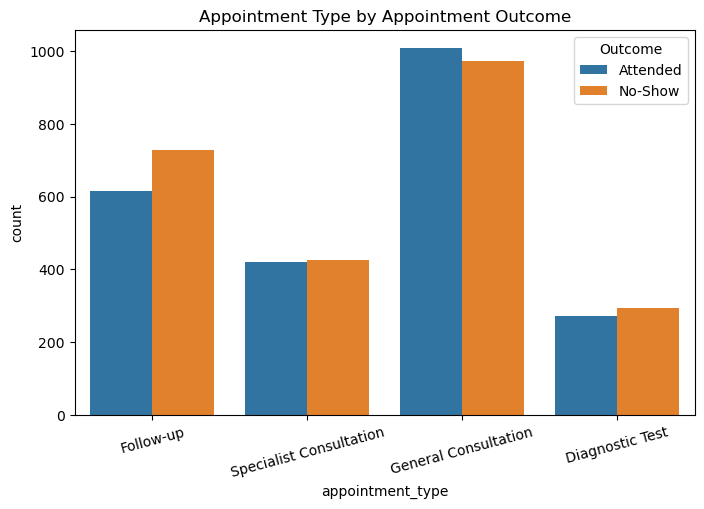

In [145]:
plt.figure(figsize=(8,5))
sns.countplot(x='appointment_type', hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Appointment Type by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Appointment Type by Outcome**: 

Follow-up appointments show a visibly higher proportion of No-Shows compared to Attended (~730 vs ~615), unlike the other appointment types where the split is close to even (General Consultation, Specialist Consultation, Diagnostic Test). This suggests appointment type may carry some predictive value, particularly around Follow-up visits, though this would need to be confirmed through formal statistical testing.

4. gender vs appointment_outcome

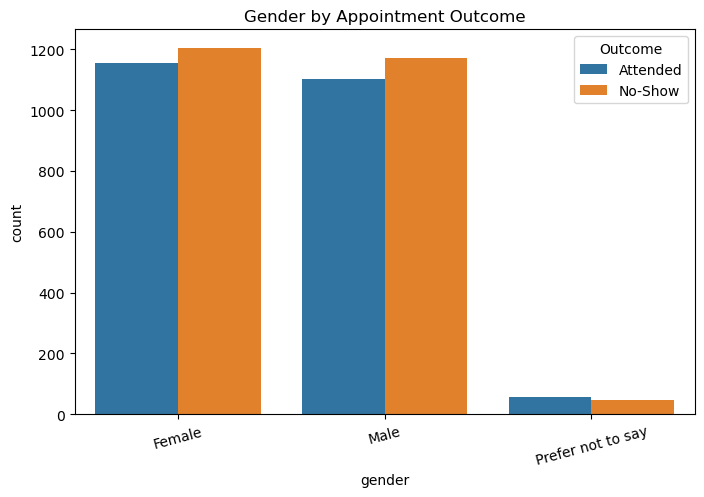

In [146]:
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Gender by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Gender by Outcome**: 

All three gender categories (Female, Male, Prefer not to say) show a similar Attended/No-Show split, with no group standing out. This suggests gender does not carry a strong predictive relationship with appointment outcome, and is a candidate for exclusion from the model and this is consistent with the ethical concern raised in Week 4 about avoiding unverified demographic assumptions as predictors.

5. age_group vs appointment_outcome

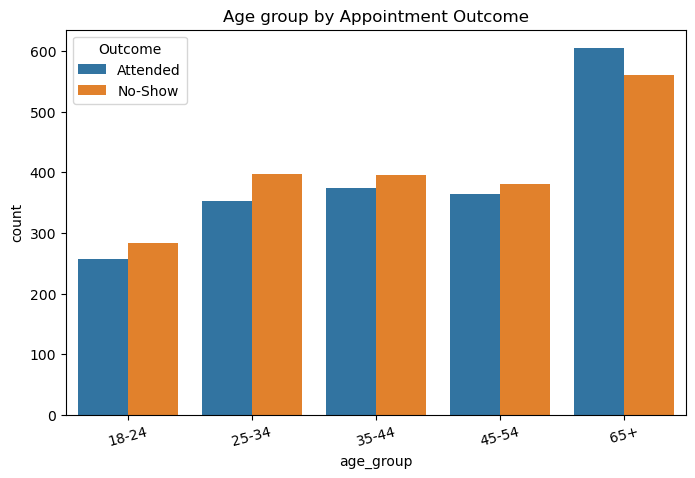

In [147]:
plt.figure(figsize=(8,5))
sns.countplot(x='age_group',order=['18-24','25-34', '35-44', '45-54', '65+'], hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Age group by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Age Group by Outcome**: 

Almost all age groups show slightly more No-Shows than Attended, except 65+, which is the only group where Attended outnumbers No-Show. The difference within each band is modest and this suggest that this variable is a mild predictor. This loosely aligns with age itself showing only a borderline relationship with outcome in earlier analysis.

6. appointment_day vs appointment_outcome

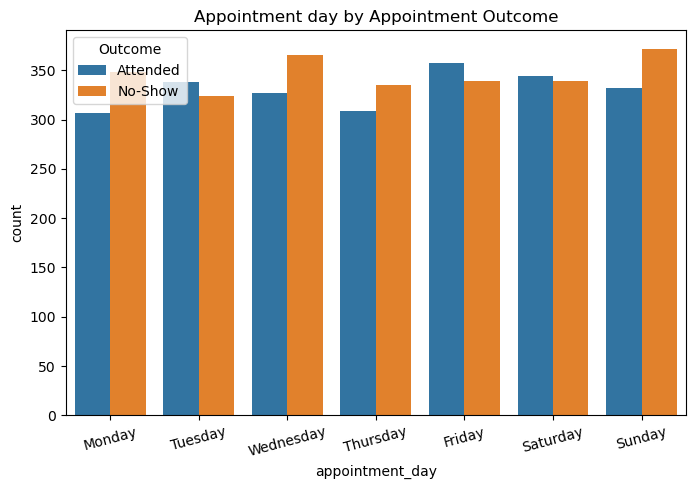

In [148]:
plt.figure(figsize=(8,5))
sns.countplot(x='appointment_day',order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Appointment day by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Appointment Day by Outcome**: 

There's no clear pattern by day of the week. Wednesday and Sunday have a few more No-Shows, and Friday and Saturday have a few more Attended, but the differences are small and don't form any obvious pattern (like weekends being worse than weekdays). This looks more like random variation than a real trend but this will be confirmed with a proper statistical test later.

7. appointment_time vs appointment_outcome

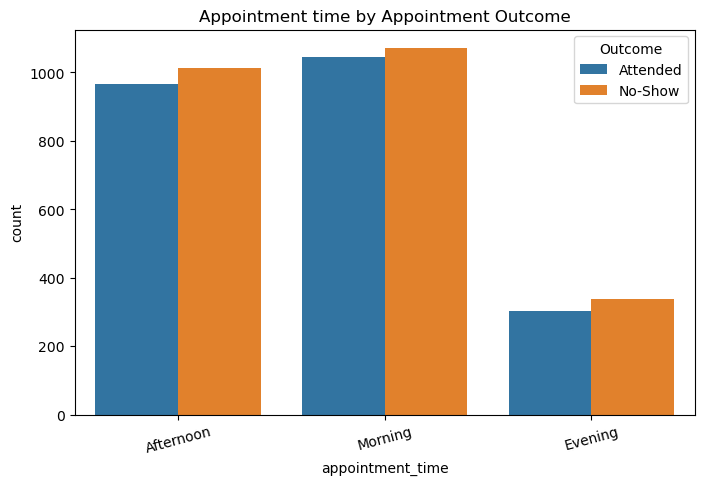

In [149]:
plt.figure(figsize=(8,5))
sns.countplot(x='appointment_time', hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Appointment time by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Appointment Time by Outcome**: 

Morning, Afternoon, and Evening all show a similar pattern. They all show a slightly more No-Shows than Attended in each, with no time slot standing out as different from the others. Appointment time does not appear to have a meaningful relationship with attendance.

8. reminder_channel vs appointment_outcome

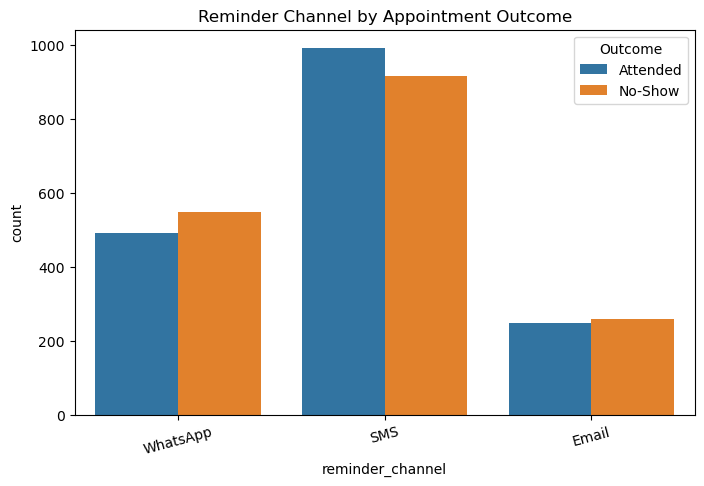

In [150]:
plt.figure(figsize=(8,5))
sns.countplot(x='reminder_channel', hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Reminder Channel by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Reminder Channel by Outcome**: 

SMS reminders are associated with a noticeably higher Attended count relative to No-Show, while WhatsApp shows the opposite way. Email is roughly even. This suggests reminder channel may have a real, actionable relationship with attendance, a pattern worth confirming statistically, since it points to a potential intervention (e.g. shifting more reminders to SMS).

9. reminder_sent vs appointment_outcome

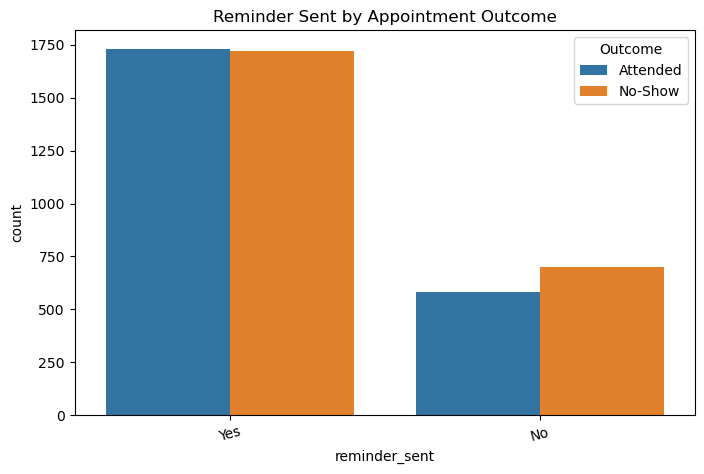

In [151]:
plt.figure(figsize=(8,5))
sns.countplot(x='reminder_sent', hue='appointment_outcome', data=HealthConnect_ML_Processed)
plt.title('Reminder Sent by Appointment Outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

**Reminder Sent by Outcome**: 

Patients who received a reminder are split almost evenly between Attended and No-Show. Patients who did not receive a reminder show a bit more No-Shows than Attended, but the difference is small. This chart alone doesn't clearly show that reminders improve attendance so a proper statistical test will be needed to confirm whether this small difference is meaningful.

### Task 2b: Data Exploration & Visual Evidence — Summary

**Numeric variables**: All six numeric variables were checked for shape and outliers. previous_appointments, previous_no_shows, distance_to_clinic_km, and waiting_time_minutes showed right-skewed distributions with legitimate outliers (not errors), supporting median imputation where missing values exist. Age and booking_lead_days showed no strong skew or outliers.

**Categorical variables**: All seven categorical variables were checked for distribution. Most were reasonably balanced, with gender "Prefer not to say" group and appointment_time "Evening" group being the smallest subgroups, both retained, but noted as having less statistical power.

**Target variable**: appointment_outcome is nearly balanced (48.9% Attended, 51.1% No-Show), which is favourable for baseline modelling.

**Correlation heatmap**: Among numeric variables, booking_lead_days (0.29) and previous_no_shows (0.12) showed the strongest correlation with the target while the rest were close to zero.

**Feature-target relationship plots**: 
- booking_lead_days showed a clear, visible difference between Attended and No-Show groups.
- previous_no_shows showed no visible difference in its boxplot, despite a weak positive correlation which is likely because most patients share the same value (0).
- Among categorical features, appointment_type (particularly Follow-up) and reminder_channel (particularly SMS) showed the most visible differences between Attended and No-Show. Gender, age_group, appointment_day, appointment_time, and reminder_sent showed little to no visible difference.

#### Feature Selection

These visual impressions above will be confirmed with formal statistical testing (t-tests for numeric variables, chi-square tests for categorical variables) before finalising the feature list for modelling.

##### Statistical Testing — Numeric Variables (T-Tests)

In [152]:
HealthConnect_ML_Processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4737 entries, 0 to 4736
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         4737 non-null   object 
 1   patient_id             4737 non-null   object 
 2   gender                 4737 non-null   object 
 3   age                    4737 non-null   int64  
 4   age_group              4737 non-null   object 
 5   appointment_type       4737 non-null   object 
 6   booking_date           4737 non-null   object 
 7   appointment_date       4737 non-null   object 
 8   appointment_day        4737 non-null   object 
 9   appointment_time       4737 non-null   object 
 10  booking_lead_days      4737 non-null   int64  
 11  previous_appointments  4737 non-null   int64  
 12  previous_no_shows      4737 non-null   int64  
 13  reminder_sent          4737 non-null   object 
 14  reminder_channel       3452 non-null   object 
 15  dist

In [153]:
##Age vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['age']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['age']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean age (Attended):", attended.mean())
print("Mean age (No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean age (Attended): 49.2476231633535
Mean age (No-Show): 48.21502269913331
T-statistic: 1.957400947491001
P-value: 0.05035924909665594


The p-value is right at the standard 0.05 cutoff. This means age does not technically meet the threshold for statistical significance, though it is very close. The actual difference in average age between the two groups is small (about 1 year). A final decision on whether to keep or drop age will be made after comparing this result with age_group

In [154]:
## booking_lead_days vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['booking_lead_days']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['booking_lead_days']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean booking_lead_days (Attended):", attended.mean())
print("Mean booking_lead_days(No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean booking_lead_days (Attended): 24.521175453759724
Mean booking_lead_days(No-Show): 34.52661989269501
T-statistic: -20.640118262265688
P-value: 1.0713758390903582e-90


The p-value is far below the 0.05 threshold, making this an extremely strong, statistically significant result. This confirms the pattern seen earlier in the boxplot where patients with no-show book their appointments considerably further in advance (about 10 days more, on average) than patients who attend. booking_lead_days is a strong candidate feature for the model.

In [155]:
## previous_appointments vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['previous_appointments']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['previous_appointments']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean previous_appointments (Attended):", attended.mean())
print("Mean previous_appointments(No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean previous_appointments (Attended): 2.9477095937770095
Mean previous_appointments(No-Show): 3.095749071399092
T-statistic: -2.923113124851388
P-value: 0.00348193178736979


The p-value is below 0.05, so this result counts as statistically significant. But looking at the actual numbers, the two groups are almost the same — only about 0.15 apart. So even though the test says the difference is real and not random luck, the difference itself is tiny and may not actually help much when predicting no-shows. This is treated as a weak feature.

In [156]:
## previous_no_shows vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['previous_no_shows']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['previous_no_shows']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean previous_no_shows (Attended):", attended.mean())
print("Mean previous_no_shows(No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean previous_no_shows (Attended): 0.4567847882454624
Mean previous_no_shows(No-Show): 0.6413536937680562
T-statistic: -8.551896231204342
P-value: 1.6193369628494876e-17


The p-value is far below 0.05, so this is a strong, statistically significant result. Patients who were no-show had, on average, more previous no-shows (0.64) than patients who attended (0.46). This confirms that even though the boxplot didn't show a clear visual difference (because most patients share the same value of 0), the test still detects a real pattern. previous_no_shows is a useful feature to keep.

In [157]:
## distance_to_clinic_km vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['distance_to_clinic_km']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['distance_to_clinic_km']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean distance_to_clinic_km (Attended):", attended.mean())
print("Mean distance_to_clinic_km(No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean distance_to_clinic_km (Attended): 9.6523768366465
Mean distance_to_clinic_km(No-Show): 10.495955427156417
T-statistic: -4.446275676225853
P-value: 8.937896971904088e-06


The p-value is far below 0.05, so this is statistically significant. Patients who are no-show live, on average, slightly further from the clinic (10.50 km) than patients who attend (9.65 km). The gap is modest in real-world terms (under 1 km), but the test confirms it's a real pattern, not chance. distance_to_clinic_km is a valid, if moderate, feature to keep.

In [158]:
## waiting_time_minutes vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['waiting_time_minutes']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['waiting_time_minutes']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean waiting_time_minutes(Attended):", attended.mean())
print("Mean waiting_time_minutes (No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean waiting_time_minutes(Attended): 24.286516853932586
Mean waiting_time_minutes (No-Show): 24.197688815517953
T-statistic: 0.2825325183981937
P-value: 0.7775476111484795


The p-value is far above 0.05, so this result is not statistically significant. The average waiting time is nearly identical between the two groups, meaning there's no real evidence that waiting time is related to appointment outcome. waiting_time_minutes will be dropped from the candidate feature list.

##### Statistical Testing — Categorical Variables (chi square-Tests)

In [159]:
## Gender vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['gender'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("Gender:", chi2_1, p1)

Gender: 1.8253757429105775 0.4014437434088165


The p-value is far above 0.05, so this result is not statistically significant. This confirms what the earlier countplot suggested that gender does not have a meaningful relationship with appointment outcome. Combined with the ethical concern raised in Week 4 about avoiding unverified demographic assumptions, gender will be dropped from the candidate feature list.

In [160]:
## Age group vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['age_group'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("age_group:", chi2_1, p1)

age_group: 6.800993121631239 0.2358663941465005


The p-value is above 0.05, so this result is not statistically significant. This confirms the mild pattern seen earlier in the countplot (the slight 65+ difference) was not strong enough to be a real, reliable effect. age_group will be dropped from the candidate feature list and this is consistent with age also being borderline/weak in the numeric test.

In [161]:
## Appointment type vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['appointment_type'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("appointment_type:", chi2_1, p1)

appointment_type: 8.422134245570703 0.038047408024352615


The p-value is below 0.05, so this result is statistically significant. This confirms the pattern seen in the earlier countplot, where Follow-up appointments showed a noticeably higher proportion of No-Shows compared to the other appointment types. appointment_type is a valid feature to keep, though the p-value is not far below the 0.05 cutoff, so the relationship is significant but not overwhelmingly strong.

In [162]:
## Appointment day vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['appointment_day'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("appointment_day:", chi2_1, p1)

appointment_day: 6.37707609375249 0.38230101724583543


The p-value is well above 0.05, so this result is not statistically significant. This confirms the earlier countplot finding that no day of the week shows a meaningful, reliable difference in attendance. appointment_day will be dropped from the candidate feature list.

In [163]:
## Appointment time vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['appointment_time'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("appointment_time:", chi2_1, p1)

appointment_time: 0.779639056482431 0.6771790751696558


The p-value is far above 0.05, so this result is not statistically significant. This confirms the earlier countplot finding that is Morning, Afternoon, and Evening all show a similar attendance pattern, with no meaningful difference. appointment_time will be dropped from the candidate feature list.

In [164]:
## Reminder sent vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['reminder_sent'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("reminder_sent:", chi2_1, p1)

reminder_sent: 8.355558884035405 0.003845091835796708


The p-value is well below 0.05, so this result is statistically significant. Even though the difference looked small in the earlier countplot, the test confirms it's a real, reliable pattern, not random chance, patients who did not receive a reminder are more likely to no-show. reminder_sent is a valid feature to keep.

In [165]:
## Reminder channel vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['reminder_channel'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("reminder_channel:", chi2_1, p1)

reminder_channel: 6.40483056956559 0.040663870446928346


The p-value is below 0.05, so this result is statistically significant. This confirms the earlier countplot pattern, where SMS reminders were associated with better attendance compared to WhatsApp. reminder_channel is a valid feature to keep, though like appointment_type, the p-value is close to the 0.05 cutoff, so the relationship is real but not very strong.

### Task 2b: Data Exploration & Visual Evidence — Final Summary and Feature Selection

All candidate features from Week 4 were tested against `appointment_outcome` using t-tests (numeric variables) and chi-square tests (categorical variables), following the visual exploration done earlier in this section.

| Feature | Type | P-value | Decision | Notes |
|---|---|---|---|---|
| booking_lead_days | Numeric | ≈ 0 | ✅ Keep | Strongest predictor; No-Show patients book far in advance |
| previous_no_shows | Numeric | ≈ 0 | ✅ Keep | Patients with more prior no-shows are more likely to no-show again |
| distance_to_clinic_km | Numeric | ≈ 0 | ✅ Keep | Patients further from the clinic are slightly more likely to no-show |
| reminder_sent | Categorical | 0.0038 | ✅ Keep | Patients without a reminder are more likely to no-show |
| previous_appointments | Numeric | 0.0035 | ✅ Keep (weak) | Significant, but real-world difference is small |
| reminder_channel | Categorical | 0.041 | ✅ Keep (weak) | SMS associated with better attendance than WhatsApp |
| appointment_type | Categorical | 0.038 | ✅ Keep (weak) | Follow-up appointments show a higher no-show rate |
| age | Numeric | 0.050 | ✅ Keep (borderline) | Right at the significance threshold; retained given plausibility as a clinical factor |
| waiting_time_minutes | Numeric | 0.78 | ❌ Drop | No meaningful relationship with outcome |
| gender | Categorical | 0.401 | ❌ Drop | Not significant; also dropped on ethical grounds (Week 4 concern re: demographic assumptions) |
| age_group | Categorical | 0.236 | ❌ Drop | Not significant; redundant with age |
| appointment_day | Categorical | 0.382 | ❌ Drop | No meaningful relationship with outcome |
| appointment_time | Categorical | 0.677 | ❌ Drop | No meaningful relationship with outcome |

This finalized list will carry forward into Task 3 (Feature Engineering), where the raw booking_date/appointment_date fields will also be revisited to derive additional signal (e.g. month or season), as previously flagged.

In [166]:
HealthConnect_ML_Processed = HealthConnect_ML_Processed.drop(columns=['appointment_id', 'waiting_time_minutes', 'gender', 'age_group', 'appointment_day', 'appointment_time'])

In [167]:
HealthConnect_ML_Processed.columns

Index(['patient_id', 'age', 'appointment_type', 'booking_date',
       'appointment_date', 'booking_lead_days', 'previous_appointments',
       'previous_no_shows', 'reminder_sent', 'reminder_channel',
       'distance_to_clinic_km', 'appointment_outcome'],
      dtype='object')

In [168]:
HealthConnect_ML_Processed['appointment_date'] = pd.to_datetime(HealthConnect_ML_Processed['appointment_date'])

HealthConnect_ML_Processed['appointment_month'] = HealthConnect_ML_Processed['appointment_date'].dt.month
HealthConnect_ML_Processed['appointment_month_name'] = HealthConnect_ML_Processed['appointment_date'].dt.month_name()

In [169]:
HealthConnect_ML_Processed.columns

Index(['patient_id', 'age', 'appointment_type', 'booking_date',
       'appointment_date', 'booking_lead_days', 'previous_appointments',
       'previous_no_shows', 'reminder_sent', 'reminder_channel',
       'distance_to_clinic_km', 'appointment_outcome', 'appointment_month',
       'appointment_month_name'],
      dtype='object')

In [170]:
HealthConnect_ML_Processed.head()

,patient_id,age,appointment_type,booking_date,appointment_date,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,appointment_outcome,appointment_month,appointment_month_name
0,P-1613,39,Follow-up,2/6/2025,2025-02-18,12,2,0,Yes,WhatsApp,19.3,1,2,February
1,P-0813,31,Specialist Consultation,2/25/2026,2026-02-27,2,6,0,Yes,SMS,14.3,0,2,February
2,P-1366,50,General Consultation,11/16/2025,2025-12-24,38,5,1,Yes,SMS,11.4,1,12,December
3,P-1031,59,Follow-up,7/18/2025,2025-08-28,41,3,1,Yes,SMS,7.4,0,8,August
4,P-1458,34,Follow-up,7/9/2025,2025-08-25,47,3,1,Yes,Email,5.6,1,8,August


### Feature Engineering

In [171]:
HealthConnect_ML_Processed['is_first_time_patient'] = (HealthConnect_ML_Processed['previous_appointments'] == 0).astype(int)

HealthConnect_ML_Processed['prior_no_show_rate'] = HealthConnect_ML_Processed['previous_no_shows'] / HealthConnect_ML_Processed['previous_appointments']

HealthConnect_ML_Processed['prior_no_show_rate'] = HealthConnect_ML_Processed['prior_no_show_rate'].fillna(0)

In [172]:
HealthConnect_ML_Processed.head()

,patient_id,age,appointment_type,booking_date,appointment_date,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,appointment_outcome,appointment_month,appointment_month_name,is_first_time_patient,prior_no_show_rate
0,P-1613,39,Follow-up,2/6/2025,2025-02-18,12,2,0,Yes,WhatsApp,19.3,1,2,February,0,0.000000
1,P-0813,31,Specialist Consultation,2/25/2026,2026-02-27,2,6,0,Yes,SMS,14.3,0,2,February,0,0.000000
2,P-1366,50,General Consultation,11/16/2025,2025-12-24,38,5,1,Yes,SMS,11.4,1,12,December,0,0.200000
3,P-1031,59,Follow-up,7/18/2025,2025-08-28,41,3,1,Yes,SMS,7.4,0,8,August,0,0.333333
4,P-1458,34,Follow-up,7/9/2025,2025-08-25,47,3,1,Yes,Email,5.6,1,8,August,0,0.333333


### Task 3: Feature Engineering

Three new features are planned for engineering from the existing dataset, building on the finalized feature list from Task 2b.

**1. Prior No-Show Rate (prior_no_show_rate)**

*What was created:* A planned new feature, calculated as previous_no_shows ÷ previous_appointments.

*Why it was created:* The raw previous_no_shows count can be misleading on its own, since the same number means different things depending on how many total appointments a patient has had. For example, 2 previous no-shows out of 2 total appointments (a 100% miss rate) is a very different risk profile from 2 previous no-shows out of 10 total appointments (a 20% miss rate), but the raw count alone treats both patients the same. Expressing this as a rate will capture the patient's actual reliability pattern rather than just a raw tally.

*Expected modelling value:* Expected to carry more predictive signal than previous_no_shows alone, since it will directly reflect the proportion of missed appointments rather than an absolute count. It will complement previous_no_shows and previous_appointments, which remain in the dataset individually as well.

**2. First-Time Patient Flag (is_first_time_patient)**

*What was created:* A planned new binary feature, set to 1 when previous_appointments == 0, and 0 otherwise. This is created alongside prior_no_show_rate, since calculating that rate requires deciding what to do when previous_appointments is 0 (which would otherwise cause a division-by-zero problem).

*Why it was created:* For patients with no previous appointments, prior_no_show_rate will be set to 0 (since they have no recorded no-shows), but this would make them look identical to a returning patient with a perfect attendance history, who would also have a rate of 0. Without a separate flag, the model would lose the distinction between "no history at all" and "proven reliable." This flag will preserve that difference explicitly.

*Expected modelling value:* Will allow the model to treat brand-new patients differently from long-standing reliable patients, even when their prior_no_show_rate values look the same. Also gives the model a chance to learn whether being a first-time patient is itself associated with a different no-show risk, independent of history.

**3. Appointment Month / Season (appointment_month)**

*What was created:* A planned new feature, extracted from appointment_date

*Why it was created:* During Task 2a, appointment_date was excluded from direct use in its raw form, since a specific calendar date doesn't generalize well as a model input. However, the date carries potentially useful information not captured elsewhere — such as seasonal patterns in attendance (e.g. holiday periods, school terms, or weather-related travel difficulty). This was flagged earlier as something to revisit rather than discard.

*Expected modelling value:* If attendance follows a seasonal pattern, this feature will let the model pick up on that signal, which none of the currently retained features capture. Its actual usefulness will be checked with the same visual and statistical approach used for the other features before deciding whether to keep it in the final model.

**Summary:** These three engineered features will be added to the modelling dataset alongside the finalized feature list from Task 2b, and each will be checked for its own relationship with appointment_outcome before being confirmed as part of the baseline model's inputs.

##### Statistical Testing — Engineered Features

In [173]:
## prior_no_show_rate vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['prior_no_show_rate']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['prior_no_show_rate']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean prior_no_show_rate (Attended):", attended.mean())
print("Mean prior_no_show_rate(No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean prior_no_show_rate (Attended): 0.14602797327516426
Mean prior_no_show_rate(No-Show): 0.1911863609861959
T-statistic: -6.399749977460051
P-value: 1.7068452309512446e-10


The p-value is far below 0.05, so this result is statistically significant. Patients who didn't show up had a higher average no-show rate in their past appointments (about 19%) compared to patients who attended (about 15%). This shows that turning the no-show history into a rate (instead of just a raw count) gives an even stronger, more useful signal than previous_no_shows alone. This is a strong feature to keep

In [174]:
## is_first_time_patient vs Appointment Outcome
from scipy import stats

attended = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 0]['is_first_time_patient']
no_show = HealthConnect_ML_Processed[HealthConnect_ML_Processed['appointment_outcome'] == 1]['is_first_time_patient']

t_stat, p_value = stats.ttest_ind(attended, no_show, equal_var=False)

print("Mean is_first_time_patient (Attended):", attended.mean())
print("Mean is_first_time_patient (No-Show):", no_show.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Mean is_first_time_patient (Attended): 0.05358686257562662
Mean is_first_time_patient (No-Show): 0.04292199752373091
T-statistic: 1.7102186560860466
P-value: 0.08729244595081039


The p-value is above 0.05, so this result is not statistically significant. There's only a small difference between how often first-time patients attend versus no-show, and this difference isn't strong enough to be trusted as a real pattern. However, since this feature was created mainly to support the interpretation of prior_no_show_rate (distinguishing genuinely new patients from proven-reliable ones), it may still be worth keeping for that reason, even though it doesn't independently predict the outcome on its own.

In [175]:
## appointment_ vs Appointment Outcome
from scipy import stats
contingency1 = pd.crosstab(HealthConnect_ML_Processed['appointment_month'], HealthConnect_ML_Processed['appointment_outcome'])
chi2_1, p1, dof1, expected1 = stats.chi2_contingency(contingency1)
print("appointment_month:", chi2_1, p1)

appointment_month: 15.911057278055459 0.14446510072844426


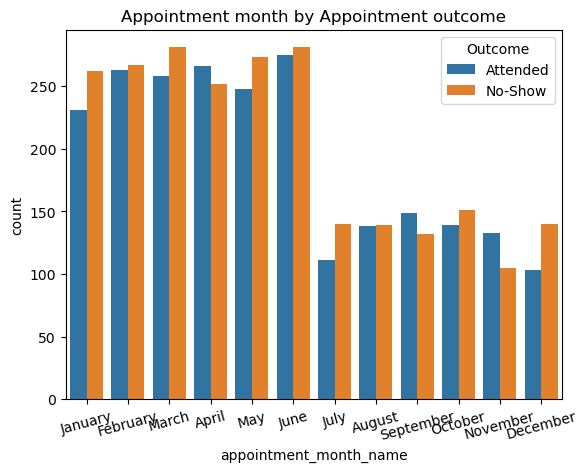

In [176]:
sns.countplot(x = 'appointment_month_name',order =['January', 'February', 'March', 'April', 
                                                   'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
              data = HealthConnect_ML_Processed, hue = 'appointment_outcome')
plt.title('Appointment month by Appointment outcome')
plt.legend(title='Outcome', labels=['Attended', 'No-Show'])
plt.xticks(rotation=15)
plt.show()

The p-value is above 0.05, so this result is not statistically significant. While the countplot shows more appointments overall in the first half of the year compared to the second half, the Attended/No-Show split within each month stays fairly consistent, meaning this reflects overall appointment volume rather than a seasonal attendance pattern. appointment_month will be dropped from the candidate feature list.

### Task 3: Feature Engineering — Summary

Three new features were engineered and tested against appointment_outcome:

| Feature | Type | P-value | Decision | Notes |
|---|---|---|---|---|
| prior_no_show_rate | Numeric |  0 | ✅ Keep | Strong, significant predictor — stronger signal than previous_no_shows alone |
| is_first_time_patient | Numeric (binary) | 0.087 | ✅ Keep (supporting role) | Not independently significant, but retained to help the model distinguish genuinely new patients from proven-reliable returning patients when interpreting prior_no_show_rate |
| appointment_month | Categorical | 0.144 | ❌ Drop | No meaningful seasonal pattern found; the visible monthly differences reflect overall appointment volume, not attendance behaviour |

prior_no_show_rate and is_first_time_patient will be added to the final modelling dataset alongside the features confirmed in Task 2b. appointment_month is dropped, and appointment_date/booking_date remain excluded from direct use, as decided in Task 2a.

In [177]:
HealthConnect_ML_Processed.columns

Index(['patient_id', 'age', 'appointment_type', 'booking_date',
       'appointment_date', 'booking_lead_days', 'previous_appointments',
       'previous_no_shows', 'reminder_sent', 'reminder_channel',
       'distance_to_clinic_km', 'appointment_outcome', 'appointment_month',
       'appointment_month_name', 'is_first_time_patient',
       'prior_no_show_rate'],
      dtype='object')

In [178]:
HealthConnect_ML_Processed = HealthConnect_ML_Processed.drop(columns = ['appointment_month', 'appointment_month_name'])

In [179]:
HealthConnect_ML_Processed.head()

,patient_id,age,appointment_type,booking_date,appointment_date,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,appointment_outcome,is_first_time_patient,prior_no_show_rate
0,P-1613,39,Follow-up,2/6/2025,2025-02-18,12,2,0,Yes,WhatsApp,19.3,1,0,0.000000
1,P-0813,31,Specialist Consultation,2/25/2026,2026-02-27,2,6,0,Yes,SMS,14.3,0,0,0.000000
2,P-1366,50,General Consultation,11/16/2025,2025-12-24,38,5,1,Yes,SMS,11.4,1,0,0.200000
3,P-1031,59,Follow-up,7/18/2025,2025-08-28,41,3,1,Yes,SMS,7.4,0,0,0.333333
4,P-1458,34,Follow-up,7/9/2025,2025-08-25,47,3,1,Yes,Email,5.6,1,0,0.333333


### Task 4: Train/Test Strategy

**Chosen approach:**

A patient-level (group-based) 80/20 train/test split, using patient_id as the grouping variable, with random_state=42 for reproducibility.

**Why this approach is appropriate:** 

The dataset contains 4,737 appointments across only 1,680 unique patients, meaning many patients have multiple appointment records. A standard random row-level split risks placing appointments from the same patient in both the training and test sets. This would allow the model to indirectly learn patient-specific patterns during training and then "recognize" that same patient in testing, inflating performance in a way that would not hold up on genuinely new, unseen patients. A patient-level split ensures that all appointments belonging to a given patient fall entirely within either the training set or the test set, giving a more realistic estimate of how the model would perform on new patients in practice.

In [180]:
from sklearn.model_selection import GroupShuffleSplit

X = HealthConnect_ML_Processed.drop(columns=['appointment_outcome'])
y = HealthConnect_ML_Processed['appointment_outcome']
groups = HealthConnect_ML_Processed['patient_id']

In [181]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [182]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3771, 13)
Test size: (966, 13)


In [183]:
# Confirming that no patient appears in both the training and testing sets
overlap = set(HealthConnect_ML_Processed.loc[train_idx, 'patient_id']) & set(HealthConnect_ML_Processed.loc[test_idx, 'patient_id'])
print("Number of overlapping patients:", len(overlap))

Number of overlapping patients: 0


In [184]:
HealthConnect_ML_Processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4737 entries, 0 to 4736
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   patient_id             4737 non-null   object        
 1   age                    4737 non-null   int64         
 2   appointment_type       4737 non-null   object        
 3   booking_date           4737 non-null   object        
 4   appointment_date       4737 non-null   datetime64[ns]
 5   booking_lead_days      4737 non-null   int64         
 6   previous_appointments  4737 non-null   int64         
 7   previous_no_shows      4737 non-null   int64         
 8   reminder_sent          4737 non-null   object        
 9   reminder_channel       3452 non-null   object        
 10  distance_to_clinic_km  4737 non-null   float64       
 11  appointment_outcome    4737 non-null   int64         
 12  is_first_time_patient  4737 non-null   int64         
 13  pri

### Task 5: Baseline Model
#### Preparing Data for Modelling

Before training the baseline model, the following preprocessing steps will be applied to X_train and X_test:

**1. Dropping non-feature columns:** patient_id, booking_date, and appointment_date will be removed. patient_id had already served its purpose for the patient-level train/test split and carries no predictive value itself. booking_date and appointment_date were never intended as direct model inputs, since their relevant information is already captured by booking_lead_days.

**2. Handling missing values in `reminder_channel`:** The 1,285 missing values in this column are not random because they correspond exactly to appointments where the variable reminder_sent = No, as confirmed in earlier analysis. Rather than dropping these rows or silently encoding them as all-zero, missing values will be filled with an explicit new category, **No Reminder**, so the model can recognise and learn from this pattern directly.

**3. One-hot encoding categorical variables:** appointment_type, reminder_sent, and reminder_channel will be converted into numeric dummy variables using one-hot encoding, since Logistic Regression requires numeric input. 

**4. Scaling numeric features:** Logistic Regression is sensitive to differences in feature scale, unlike tree-based models. Since previous_appointments, previous_no_shows, and distance_to_clinic_km were identified during EDA as right-skewed with legitimate outliers, RobustScaler will be used (scaling based on median and interquartile range rather than mean and standard deviation, making it less sensitive to those outliers).

In [185]:
X_train = X_train.drop(columns=['patient_id', 'booking_date', 'appointment_date'])
X_test = X_test.drop(columns=['patient_id', 'booking_date', 'appointment_date'])

In [186]:
# Fill missing reminder_channel with an explicit category
X_train['reminder_channel'] = X_train['reminder_channel'].fillna('No Reminder')
X_test['reminder_channel'] = X_test['reminder_channel'].fillna('No Reminder')

In [187]:
# One-hot encode categorical columns
X_train = pd.get_dummies(X_train, columns=['appointment_type', 'reminder_sent', 'reminder_channel'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['appointment_type', 'reminder_sent', 'reminder_channel'], drop_first=True)

In [188]:
# Align train and test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [189]:
# Scale numeric features
from sklearn.preprocessing import RobustScaler

numeric_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 
                'distance_to_clinic_km', 'prior_no_show_rate']

scaler = RobustScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [190]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3771 entries, 0 to 4733
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   age                                       3771 non-null   float64
 1   booking_lead_days                         3771 non-null   float64
 2   previous_appointments                     3771 non-null   float64
 3   previous_no_shows                         3771 non-null   float64
 4   distance_to_clinic_km                     3771 non-null   float64
 5   is_first_time_patient                     3771 non-null   int64  
 6   prior_no_show_rate                        3771 non-null   float64
 7   appointment_type_Follow-up                3771 non-null   bool   
 8   appointment_type_General Consultation     3771 non-null   bool   
 9   appointment_type_Specialist Consultation  3771 non-null   bool   
 10  reminder_sent_Yes                        

In [191]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 966 entries, 9 to 4736
Data columns (total 14 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   age                                       966 non-null    float64
 1   booking_lead_days                         966 non-null    float64
 2   previous_appointments                     966 non-null    float64
 3   previous_no_shows                         966 non-null    float64
 4   distance_to_clinic_km                     966 non-null    float64
 5   is_first_time_patient                     966 non-null    int64  
 6   prior_no_show_rate                        966 non-null    float64
 7   appointment_type_Follow-up                966 non-null    bool   
 8   appointment_type_General Consultation     966 non-null    bool   
 9   appointment_type_Specialist Consultation  966 non-null    bool   
 10  reminder_sent_Yes                         

### Task 5: Baseline Model

**Model selected:** Logistic Regression.

**Reason for selection:** The target variable, appointment_outcome, only has two possible values which is either Attended or No-Show, making this a binary classification problem. Logistic Regression is specifically built for this kind of problem. it estimates the probability of one of two outcomes occurring, unlike models such as Linear Regression, which are designed to predict continuous numbers and would not be appropriate here.

Beyond fitting the type of problem, Logistic Regression was also proposed in Week 4 as the initial baseline model, and remains a strong choice for this stage for two further reasons: it is simple and fast to train, and it is highly interpretable. Each feature gets a coefficient showing its direction and relative strength of influence on the prediction, which makes it easy to explain to non-technical stakeholders (e.g. "longer booking lead time increases no-show risk"). Since the goal of Week 5 is to establish a reliable baseline rather than the best-performing model, Logistic Regression is a sensible starting point before considering more complex models (e.g. Random Forest, as noted in week 4).

**Training process:** The model was trained on X_train/y_train (the preprocessed, encoded, and scaled training set). max_iter was increased to 1000 to give the model enough rounds to fully converge, since the default limit (100) was not enough for this dataset. class_weight= balanced was used so the model pays proportionally fair attention to both outcome classes, given the target is close to even but not perfectly balanced (48.9% Attended vs 51.1% No-Show).

In [192]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

In [193]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")

Accuracy: 0.63
Precision: 0.63
Recall: 0.62
F1 Score: 0.62


### Task 6: Initial Evaluation — Classification Metrics

- Accuracy: 0.63
- Precision (No-Show): 0.63
- Recall (No-Show): 0.62
- F1 Score: 0.62

The most important number here is recall, because for HealthConnect, missing a real no-show is worse than wrongly flagging someone who was actually going to come. Recall of 0.62 means the model correctly spots 62 out of every 100 patients who actually had no-show, it misses the other 38. Precision of 0.63 means that when the model says "this patient will no-show," it's correct 63% of the time. So the model works better than pure guesswork, but it still misses a good number of real no-shows. Since this is just the first, baseline model, that's okay for now and the goal at this stage is to have something working, not something perfect.

In [194]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[305 178]
 [183 300]]


### Confusion Matrix

|  | Predicted: Attended | Predicted: No-Show |
|---|---|---|
| **Actual: Attended** | 305 (correct) | 178 (false alarm) |
| **Actual: No-Show** | 183 (missed) | 300 (correct) |

The model correctly identifies 300 out of 483 actual no-shows, but misses 183 of them and these are the patients HealthConnect would fail to flag for early intervention, which is the more costly error for this problem. It also incorrectly flags 178 patients who were actually going to attend, which carries a much lower cost (an unnecessary reminder). This confirms the recall score of 0.62 calculated earlier (300 ÷ 483).

In [195]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(roc_auc, 2))

ROC-AUC: 0.68


ROC-AUC measures how well the model ranks patients by no-show risk, regardless of a specific cutoff point. A score of 0.5 would mean no better than random guessing, while 1.0 would mean perfect separation between the two groups. At 0.68, the model shows a moderate ability to distinguish no-show patients from attending patients which is better than chance, but with clear room for improvement. This is consistent with the other metrics (accuracy, recall, F1 all around 0.62-0.63), confirming this is a reasonable but modest baseline.

### Modelling Limitations and Recommendations for Week 6

**Limitations:**
- The baseline model correctly catches only 62% of actual no-shows (recall), meaning a substantial portion of at-risk patients would not be flagged for intervention.
- ROC-AUC of 0.68 indicates only moderate separation between the two classes and several features included have weak individual relationships with the outcome (e.g. previous_appointments, appointment_type), which may limit the model's overall discriminative power.
- Logistic Regression assumes a linear relationship between features and the outcome; it may not capture more complex, non-linear patterns in the data.
- age was retained despite borderline/non-significant statistical test results, based on judgment rather than strong evidence and this is a reasonable but subjective choice.

**Recommendations for Week 6:**
- Test a tree-based model (e.g. Random Forest, as flagged in Week 4) to check whether it captures non-linear patterns better than Logistic Regression.
- Review feature importance/coefficients from this baseline to identify which features are actually driving predictions, and consider removing weak ones.
- Explore additional feature engineering opportunities (e.g. interaction between booking_lead_days and previous_no_shows).
- Consider hyperparameter tuning to improve recall specifically, given its priority for this business problem.

### Cross-Track Collaboration

**Track this work connects to:** Machine Learning Engineering.

**Information/output exchanged:** A message was sent to an ML Engineering intern outlining the finalized feature list, preprocessing steps (encoding, scaling, and handling of missing values in reminder_channel), the patient-level train/test split strategy, and the trained baseline Logistic Regression model, offering to share further detail if useful for their pipeline work.

**Why this interaction was relevant:** ML Engineering's Week 5 task involves implementing an initial data-processing workflow and model integration structure. This cannot be meaningfully built without knowing what features, preprocessing steps, and model type the Data Science track has settled on.

**What changed or improved as a result:** This ensures ML Engineering has access to the exact feature definitions, preprocessing logic, and model type used here, reducing the risk of duplicated or inconsistent decisions if they build a pipeline around this model.

### Part 3: Assumptions, Limitations, Risks & Dependencies

**Which remain relevant:** The patient-level train/test split remains necessary and was implemented, since the dataset contains 4,737 appointments across only 1,680 unique patients and the same leakage risk identified in Week 4 was still applied and was addressed accordingly. The ethical concern about not using unverified demographic assumptions as predictors also remained relevant and this was acted on directly, as gender was statistically tested and dropped from the model.

**Which have been resolved:** The missing data in distance_to_clinic_km and waiting_time_minutes was resolved through median imputation, as planned in Week 4. The open question of which of the 11 candidate features to actually use was resolved through statistical testing (t-tests and chi-square tests), producing a finalized, evidence-based candidate features.

**Which have changed:** waiting_time_minutes was originally treated as a candidate feature requiring imputation, but was ultimately dropped after testing showed no significant relationship with the outcome (p = 0.78) 

**New issues discovered during Week 5:** reminder_channel had missing values that could not simply be imputed like a numeric field, since missing here meant no reminder was sent, not a gap to fill in though but it required creating its own category which was subsequently named No Reminder category. Additionally, testing showed age (p = 0.050) was just at the significance threshold, requiring a judgment call rather than a clear-cut decision.

**Potential impact on the project:** The baseline model's moderate performance (62% recall, ROC-AUC 0.68) suggests the current feature set captures a real but limited amount of the pattern behind no-shows. If this isn't improved, HealthConnect would still miss a meaningful share of at-risk patients even with the model in place.

**How they should be addressed:** These will be addressed in Week 6 by testing alternative models (e.g. Random Forest, as proposed in Week 4) to check for non-linear patterns the current model may be missing, and by revisiting the borderline features once a stronger model is in place to see whether their contribution changes.